# Qualitätsregelkarte mit Python

Diese Aufgabe beinhaltet:

- Simulation von Messdaten
- Qualitätsregelkarte
- Cp und Cpk Berechnung
- Normalverteilungstest
- CSV-Export

Erstellt mit Python, Pandas und Matplotlib.

Setup einfügen


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
SOLLWERT = 50.00
LSL = 49.80
USL = 50.20
ANZAHL_MESSWERTE = 100

np.random.seed(42)

Messwerte erzeugen


In [3]:
messwerte = np.random.normal(
    loc=SOLLWERT,
    scale=0.06,
    size=ANZAHL_MESSWERTE
)

Prozessdrift einbauen


In [4]:
messwerte[70:] = messwerte[70:] + 0.08


Tabelle erstellen

In [5]:
df = pd.DataFrame({
    "Messung": np.arange(1, ANZAHL_MESSWERTE + 1),
    "Durchmesser_mm": messwerte
})

df.head()

,Messung,Durchmesser_mm
0,1,50.029803
1,2,49.991704
2,3,50.038861
3,4,50.091382
4,5,49.985951


Diagramm erstellen

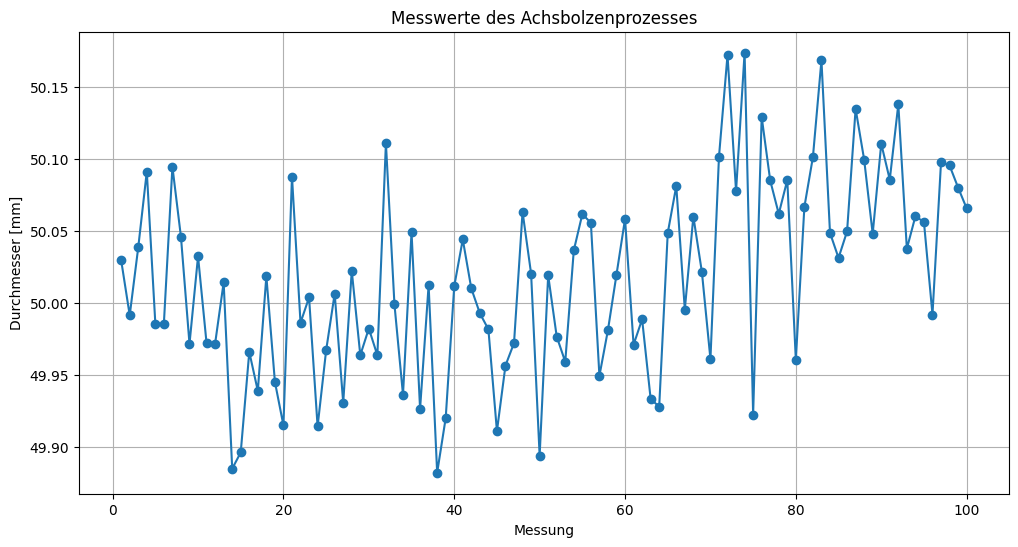

In [6]:
plt.plot(df["Messung"], df["Durchmesser_mm"], marker="o")

plt.title("Messwerte des Achsbolzenprozesses")
plt.xlabel("Messung")
plt.ylabel("Durchmesser [mm]")

plt.grid(True)

plt.show()

Statistik berechnen

In [7]:
mittelwert = df["Durchmesser_mm"].mean()

varianz = df["Durchmesser_mm"].var()

standardabweichung = df["Durchmesser_mm"].std()

minimum = df["Durchmesser_mm"].min()

maximum = df["Durchmesser_mm"].max()

ausschuss = df[
    (df["Durchmesser_mm"] < LSL) |
    (df["Durchmesser_mm"] > USL)
]

anzahl_ausschuss = len(ausschuss)

print(f"Mittelwert: {mittelwert:.4f} mm")
print(f"Varianz: {varianz:.6f}")
print(f"Standardabweichung: {standardabweichung:.4f} mm")
print(f"Minimum: {minimum:.4f} mm")
print(f"Maximum: {maximum:.4f} mm")
print(f"Ausschussteile: {anzahl_ausschuss}")

Mittelwert: 50.0178 mm
Varianz: 0.004536
Standardabweichung: 0.0674 mm
Minimum: 49.8824 mm
Maximum: 50.1739 mm
Ausschussteile: 0


Regelgrenzen berechnen

Warngrenzen (±2σ)
Eingriffsgrenzen (±3σ)

In [8]:
warn_oben = mittelwert + 2 * standardabweichung
warn_unten = mittelwert - 2 * standardabweichung

eingriff_oben = mittelwert + 3 * standardabweichung
eingriff_unten =mittelwert - 3 * standardabweichung

Qualitätsregelkarte erstellen

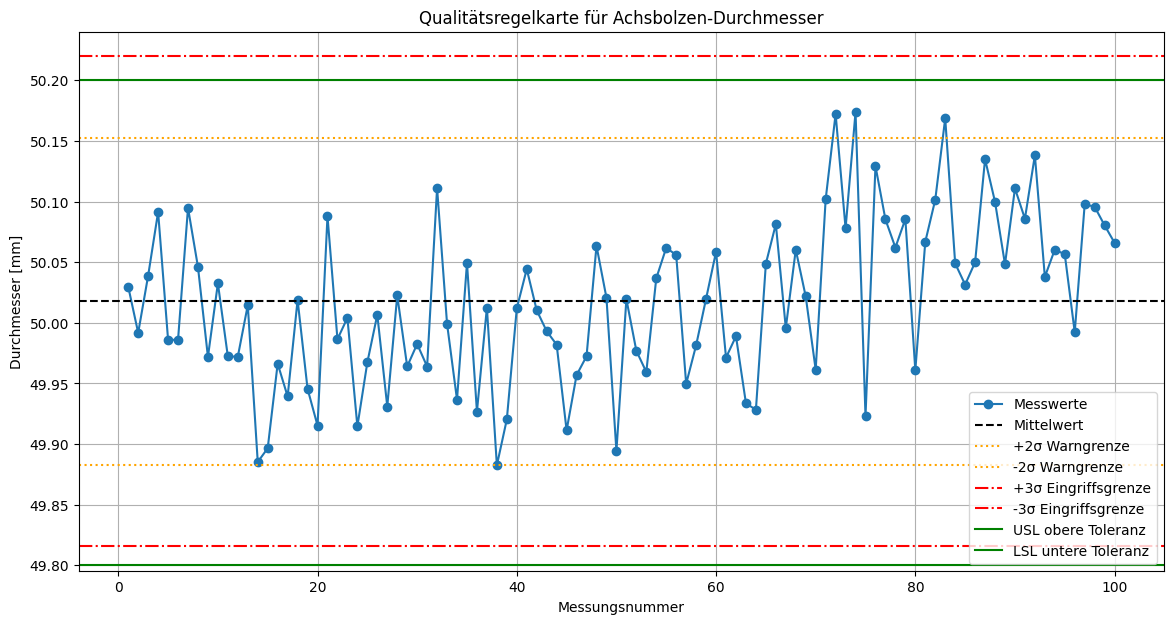

In [9]:
plt.figure(figsize=(14, 7))

plt.plot(df["Messung"], df["Durchmesser_mm"], marker="o", label="Messwerte")

plt.axhline(mittelwert, color="black", linestyle="--", label="Mittelwert")

plt.axhline(warn_oben, color="orange", linestyle=":", label="+2σ Warngrenze")
plt.axhline(warn_unten, color="orange", linestyle=":", label="-2σ Warngrenze")

plt.axhline(eingriff_oben, color="red", linestyle="-.", label="+3σ Eingriffsgrenze")
plt.axhline(eingriff_unten, color="red", linestyle="-.", label="-3σ Eingriffsgrenze")

plt.axhline(USL, color="green", linestyle="-", label="USL obere Toleranz")
plt.axhline(LSL, color="green", linestyle="-", label="LSL untere Toleranz")

plt.title("Qualitätsregelkarte für Achsbolzen-Durchmesser")
plt.xlabel("Messungsnummer")
plt.ylabel("Durchmesser [mm]")

plt.grid(True)
plt.legend()
plt.show()



Cp berechnen


In [10]:
Cp = (USL - LSL) / (6 * standardabweichung)

print(f"Cp: {Cp:.3f}")

Cp: 0.990


| Cp Wert | Bedeutung          |
| ------- | ------------------ |
| > 1.33  | sehr guter Prozess |
| ≈ 1.0   | grenzwertig        |
| < 1.0   | nicht prozessfähig |


 Cpk berechnen

In [11]:
Cpk = min(
    (USL - mittelwert) / (3 * standardabweichung),
    (mittelwert - LSL) / (3 * standardabweichung)
)

print(f"Cpk: {Cpk:.3f}")

Cpk: 0.902


Cpk < Cp
dann ist der Prozess verschoben.

 Normalverteilung testen

In [12]:
if SCIPY_AVAILABLE:
    shapiro_test = stats.shapiro(df["Durchmesser_mm"])

    print("Shapiro-Wilk-Test")
    print(f"Teststatistik: {shapiro_test.statistic:.4f}")
    print(f"p-Wert: {shapiro_test.pvalue:.4f}")

    if shapiro_test.pvalue > 0.05:
        print("Die Daten sind näherungsweise normalverteilt.")
    else:
        print("Die Daten sind nicht normalverteilt.")
else:
    print("Scipy ist nicht installiert.")

Shapiro-Wilk-Test
Teststatistik: 0.9872
p-Wert: 0.4538
Die Daten sind näherungsweise normalverteilt.


CSV-Datei speichern

In [13]:
df.to_csv("messdaten_achsbolzen.csv", index=False)

print("CSV-Datei gespeichert.")

CSV-Datei gespeichert.


Kurze Interpretation

In [14]:
print("Interpretation:")
print("Der Prozess zeigt ab Messung 70 eine Drift nach oben.")
print("Die Qualitätsregelkarte zeigt die Veränderung des Prozesses.")
print("Cp beschreibt die allgemeine Prozessfähigkeit.")
print("Cpk berücksichtigt zusätzlich die Lage des Mittelwertes.")
print("Wenn Cpk kleiner als Cp ist, ist der Prozess verschoben.")

Interpretation:
Der Prozess zeigt ab Messung 70 eine Drift nach oben.
Die Qualitätsregelkarte zeigt die Veränderung des Prozesses.
Cp beschreibt die allgemeine Prozessfähigkeit.
Cpk berücksichtigt zusätzlich die Lage des Mittelwertes.
Wenn Cpk kleiner als Cp ist, ist der Prozess verschoben.
